# Generalizability Study

In [73]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [74]:
experiment = "generalizability_study"

In [75]:
# dataset = "aitv2"
# scenario = "santos_fox"
# test_scenario = "fox"

dataset = "darpa2000"
scenario = "s1_inside_s1_dmz"
test_scenario = "s1_dmz"

In [76]:
def compute_weighted_f1(metrics):
    total_support = 0
    weighted_f1_sum = 0

    for class_name, stats in metrics['per_class'].items():
        support = stats['TP'] + stats['FN']
        total_support += support
        weighted_f1_sum += stats['f1'] * support

    weighted_f1 = weighted_f1_sum / total_support

    return weighted_f1


In [77]:
experiments = {}

In [96]:
metrics_dir = Path(f"../../experiments/{dataset}/{scenario}/{experiment}/deepproblog/metrics")
file_paths = list(metrics_dir.iterdir())

f1_scores = {}
false_positives = {}
detection_rates = {}

for file_path in file_paths:
    data = np.load(file_path, allow_pickle=True)
    metrics = data["metrics"].item()

    experiment_name = str(file_path.stem)
    if "baseline" in experiment_name:
        exp_name = f"logic_{scenario}"
    else:
        train_setting = experiment_name.split("_")[3]
        exp_name = f"dpl_{train_setting}_{scenario}"
    print(f"Experiment: {exp_name}")
    
    weighted_f1 = compute_weighted_f1(metrics)
    
    experiments[exp_name] = {
        "f1_score": metrics["macro_f1"],
        "weighted_f1": weighted_f1,
        "false_alarm_rate": metrics["false_alarm_rate"],
        "detection_rate": metrics["detection_rate"]
    }
    print(f"Weighted F1 Score: {weighted_f1}")
    print(f"Macro F1 Score: {metrics['macro_f1']}")
    for phase in metrics["per_class"]:
        print(f"Phase: {phase}")
        print(f"  F1 Score: {metrics['per_class'][phase]}")
    print()


Experiment: dpl_pretrained_s1_inside_s1_dmz
Weighted F1 Score: 0.970964778940148
Macro F1 Score: 0.8859220616534828
Phase: benign
  F1 Score: {'TP': 10580, 'FP': 1169, 'FN': 20, 'precision': 0.9005021703974806, 'recall': 0.9981132075471698, 'f1': 0.9467985144749206}
Phase: phase1
  F1 Score: {'TP': 211, 'FP': 1, 'FN': 556, 'precision': 0.9952830188679245, 'recall': 0.27509778357235987, 'f1': 0.4310520939734423}
Phase: phase2
  F1 Score: {'TP': 25, 'FP': 0, 'FN': 0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}
Phase: phase3
  F1 Score: {'TP': 75, 'FP': 0, 'FN': 4, 'precision': 1.0, 'recall': 0.9493670886075949, 'f1': 0.974025974025974}
Phase: phase4
  F1 Score: {'TP': 18, 'FP': 0, 'FN': 1, 'precision': 1.0, 'recall': 0.9473684210526315, 'f1': 0.972972972972973}
Phase: phase5
  F1 Score: {'TP': 33334, 'FP': 19, 'FN': 608, 'precision': 0.9994303361017, 'recall': 0.9820870897413234, 'f1': 0.9906828144735865}

Experiment: logic_s1_inside_s1_dmz
Weighted F1 Score: 0.8713689717475668
Macro F1 

In [79]:
metrics_dir = Path(f"../../experiments/{dataset}/{test_scenario}/{experiment}/deepproblog/metrics")
file_paths = list(metrics_dir.iterdir())

In [80]:
f1_scores = {}
false_positives = {}
detection_rates = {}

for file_path in file_paths:

    data = np.load(file_path, allow_pickle=True)
    metrics = data["metrics"].item()

    experiment_name = str(file_path.stem)
    if "baseline" in experiment_name:
        exp_name = f"logic_{test_scenario}"
    else:
        train_setting = experiment_name.split("_")[3]
        exp_name = f"dpl_{train_setting}_{test_scenario}"
    print(f"Experiment: {exp_name}")

    weighted_f1 = compute_weighted_f1(metrics)

    experiments[exp_name] = {
        "f1_score": metrics["macro_f1"],
        "weighted_f1": weighted_f1,
        "false_alarm_rate": metrics["false_alarm_rate"],
        "detection_rate": metrics["detection_rate"]
    }


Experiment: dpl_endtoend_s1_dmz
Experiment: dpl_pretrained_s1_dmz


In [81]:
metrics_dir = Path(f"../../experiments/{dataset}/{scenario}/{experiment}/baselines/metrics")
file_paths = list(metrics_dir.iterdir())

for file_path in file_paths:

    with open(file_path) as f:
        metrics = json.load(f)

    experiment_name = str(file_path.stem)
    model_name = experiment_name.split("_")[0]
    exp_name = f"lstm_{model_name}_{scenario}"
    print(f"Experiment: {exp_name}")

    weighted_f1 = compute_weighted_f1(metrics)

    experiments[exp_name] = {
        "f1_score": metrics["macro_f1"],
        "weighted_f1": weighted_f1,
        "false_alarm_rate": metrics["false_alarm_rate"],
        "detection_rate": metrics["detection_rate"]
    }


Experiment: lstm_multiclass_s1_inside_s1_dmz


In [82]:
metrics_dir = Path(f"../../experiments/{dataset}/{test_scenario}/{experiment}/baselines/metrics")
file_paths = list(metrics_dir.iterdir())

for file_path in file_paths:

    with open(file_path) as f:
        metrics = json.load(f)

    experiment_name = str(file_path.stem)
    model_name = experiment_name.split("_")[0]
    exp_name = f"lstm_{model_name}_{test_scenario}"
    print(f"Experiment: {exp_name}")

    weighted_f1 = compute_weighted_f1(metrics)

    experiments[exp_name] = {
        "f1_score": metrics["macro_f1"],
        "weighted_f1": weighted_f1,
        "false_alarm_rate": metrics["false_alarm_rate"],
        "detection_rate": metrics["detection_rate"]
    }

    print(weighted_f1)
    print(metrics["per_class"]["benign"])


Experiment: lstm_multiclass_s1_dmz
0.9992602422732594
{'TP': 3180, 'FP': 7, 'FN': 0, 'precision': 0.9978035770316912, 'recall': 1.0, 'f1': 0.9989005811214073}


In [83]:
experiments

{'dpl_pretrained_s1_inside_s1_dmz': {'f1_score': 0.8859220616534828,
  'weighted_f1': 0.970964778940148,
  'false_alarm_rate': 0.0018867924528301887,
  'detection_rate': 0.9664389067524116},
 'logic_s1_inside_s1_dmz': {'f1_score': 0.9307241522826625,
  'weighted_f1': 0.8713689717475668,
  'false_alarm_rate': 0.449622641509434,
  'detection_rate': 0.9834921910886542},
 'dpl_endtoend_s1_inside_s1_dmz': {'f1_score': 0.9123684050317012,
  'weighted_f1': 0.974365589517051,
  'false_alarm_rate': 0.003962264150943396,
  'detection_rate': 0.9697978870004593},
 'dpl_endtoend_s1_dmz': {'f1_score': 0.993670016691952,
  'weighted_f1': 0.9871320999037866,
  'false_alarm_rate': 0.00031446540880503143,
  'detection_rate': 0.9831578947368421},
 'dpl_pretrained_s1_dmz': {'f1_score': 0.9379712901398612,
  'weighted_f1': 0.9867345041912926,
  'false_alarm_rate': 0.0009433962264150943,
  'detection_rate': 0.9828708133971292},
 'lstm_multiclass_s1_inside_s1_dmz': {'f1_score': 0.4099729321275169,
  'weighte

In [84]:
plots_dir = Path(f"../../reports/{dataset}/{scenario}/{experiment}")
plots_dir.mkdir(parents=True, exist_ok=True)

In [85]:
def metrics_heatmap(
    experiments,
    selected_models=None,
    global_bounds=None,
    plots_title="",
    plots_dir=None,
    plots_name=""
):

    metrics = ["f1_score", "weighted_f1", "detection_rate", "false_alarm_rate"]

    metric_labels = ["Macro F1", "Weighted F1", "Detection Rate", "False Alarm Rate"]

    colormaps = {
        "f1_score": sns.color_palette("RdYlGn", as_cmap=True),
        "weighted_f1": sns.color_palette("RdYlGn", as_cmap=True),
        "detection_rate": sns.color_palette("RdYlGn", as_cmap=True),
        "false_alarm_rate": sns.color_palette("RdYlGn", as_cmap=True),
    }

    if selected_models is None:
        selected_models = list(experiments.keys())

    model_labels = [
        m.replace("dpl_", "")
         .replace("lstm_multiclass_", "")
         .replace("endtoend_", "")
         .replace("pretrained_", "")
         .replace("logic_", "")

         .replace("santos_fox", "SANTOS -> FOX \n")
         .replace("fox", "FOX -> FOX \n")
         .replace("s1_inside_s1_dmz", "INSIDE -> DMZ \n")
         .replace("s1_dmz", "DMZ -> DMZ \n")

        for m in selected_models
    ]

    data = np.array([
        [experiments[m][metric] for metric in metrics]
        for m in selected_models
    ])

    data_norm = np.zeros_like(data, dtype=float)
    for j, metric in enumerate(metrics):
        vmin, vmax = global_bounds[metric]
        col = data[:, j]
        col = np.clip(col, vmin, vmax)
        data_norm[:, j] = col - vmin

    # Plot
    sns.set_theme(style="white")
    
    fig_height = max(1.8, len(selected_models) * 0.65)
    fig, ax = plt.subplots(figsize=(7.5, fig_height))

    sns.heatmap(
        data_norm,
        cmap="Greys",   # placeholder; we override per-cell coloring below
        cbar=False,
        linewidths=1.5,
        linecolor="white",
        ax=ax
    )

    for i in range(data.shape[0]):
        for j, metric in enumerate(metrics):

            vmin, vmax = global_bounds[metric]
            val = data[i, j]

            if metric == "false_alarm_rate":
                norm_val = (vmax - np.clip(val, vmin, vmax)) / (vmax - vmin)
            else:
                norm_val = (np.clip(val, vmin, vmax) - vmin) / (vmax - vmin)

            color = colormaps[metric](norm_val)

            ax.add_patch(plt.Rectangle(
                (j, i), 1, 1,
                facecolor=color,
                edgecolor="white",
                linewidth=1.5
            ))

            ax.text(
                j + 0.5,
                i + 0.5,
                f"{val:.3f}",
                ha="center",
                va="center",
                fontsize=10,
                color="black" if norm_val < 0.6 else "white"
            )

    # Labels
    ax.set_xticklabels(metric_labels, rotation=0, fontsize=11)

    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    
    ax.set_yticklabels(model_labels, rotation=0, fontsize=10)

    ax.set_title(plots_title, fontsize=12, pad=18)

    plt.tight_layout()

    if plots_dir:
        plots_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(plots_dir / f"metrics_heatmap_{plots_name}.png", dpi=300, bbox_inches="tight")

    plt.show()

In [86]:
for exp_name in experiments.keys():
    print(exp_name)

dpl_pretrained_s1_inside_s1_dmz
logic_s1_inside_s1_dmz
dpl_endtoend_s1_inside_s1_dmz
dpl_endtoend_s1_dmz
dpl_pretrained_s1_dmz
lstm_multiclass_s1_inside_s1_dmz
lstm_multiclass_s1_dmz


In [87]:
def compute_global_bounds(experiments, metrics):
    bounds = {}

    for metric in metrics:
        values = [
            experiments[m][metric]
            for m in experiments
        ]

        if metric == "false_alarm_rate":
            bounds[metric] = (0.0, max(values))  # often better to anchor at 0
        else:
            bounds[metric] = (min(values), max(values))

    return bounds

In [88]:
bounds = compute_global_bounds(experiments, metrics=["f1_score", "weighted_f1", "detection_rate", "false_alarm_rate"])

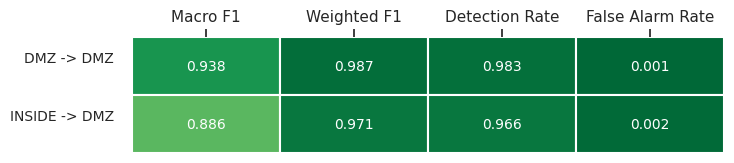

In [89]:
# Pretrained models only

top_models = [
    f"dpl_pretrained_{test_scenario}",
    f"dpl_pretrained_{scenario}",
]

metrics_heatmap(
    experiments,
    selected_models=top_models,
    global_bounds=bounds,
    # plots_title="DeepProbLog Pretrained",
    plots_dir=plots_dir,
    plots_name="dpl_pretrained"
)

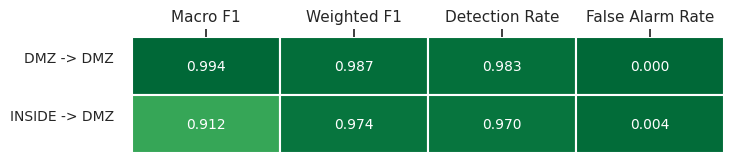

In [90]:
# Scratch models only

top_models = [
    f"dpl_endtoend_{test_scenario}",
    f"dpl_endtoend_{scenario}",
]

metrics_heatmap(
    experiments,
    selected_models=top_models,
    # plots_title="DeepProbLog End-to-End",
    global_bounds=bounds,
    plots_dir=plots_dir,
    plots_name="dpl_endtoend"
)

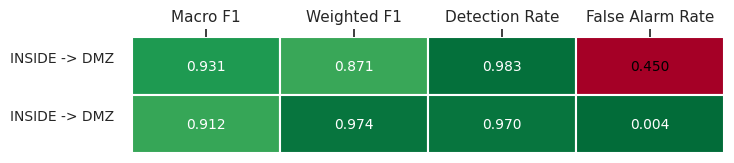

In [91]:
# Logic baseline

top_models = [
    f"logic_{scenario}",
    f"dpl_endtoend_{scenario}",
]

metrics_heatmap(
    experiments,
    selected_models=top_models,
    # plots_title="Logic Baseline",
    global_bounds=bounds,
    plots_dir=plots_dir,
    plots_name="logic_baseline"
)

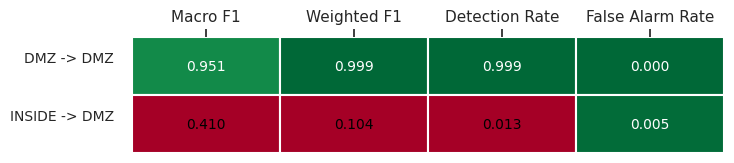

In [92]:
# Neural baseline

top_models = [
    f"lstm_multiclass_{test_scenario}",
    f"lstm_multiclass_{scenario}",
]

metrics_heatmap(
    experiments,
    selected_models=top_models,
    # plots_title="Neural Baseline",
    global_bounds=bounds, 
    plots_dir=plots_dir,
    plots_name="neural_baseline"
)

## Metrics

In [93]:
experiments_df = pd.DataFrame(experiments).T
experiments_df

,f1_score,weighted_f1,false_alarm_rate,detection_rate
dpl_pretrained_s1_inside_s1_dmz,0.885922,0.970965,0.001887,0.966439
logic_s1_inside_s1_dmz,0.930724,0.871369,0.449623,0.983492
dpl_endtoend_s1_inside_s1_dmz,0.912368,0.974366,0.003962,0.969798
dpl_endtoend_s1_dmz,0.993670,0.987132,0.000314,0.983158
dpl_pretrained_s1_dmz,0.937971,0.986735,0.000943,0.982871
lstm_multiclass_s1_inside_s1_dmz,0.409973,0.103946,0.004528,0.013407
lstm_multiclass_s1_dmz,0.950739,0.999260,0.000000,0.999330


In [94]:
experiments_sorted = experiments_df.sort_values(by='f1_score', ascending=False)
experiments_sorted

,f1_score,weighted_f1,false_alarm_rate,detection_rate
dpl_endtoend_s1_dmz,0.993670,0.987132,0.000314,0.983158
lstm_multiclass_s1_dmz,0.950739,0.999260,0.000000,0.999330
dpl_pretrained_s1_dmz,0.937971,0.986735,0.000943,0.982871
logic_s1_inside_s1_dmz,0.930724,0.871369,0.449623,0.983492
dpl_endtoend_s1_inside_s1_dmz,0.912368,0.974366,0.003962,0.969798
dpl_pretrained_s1_inside_s1_dmz,0.885922,0.970965,0.001887,0.966439
lstm_multiclass_s1_inside_s1_dmz,0.409973,0.103946,0.004528,0.013407


In [95]:
# save sorted results to CSV
experiments_sorted.to_csv(plots_dir / "generalizability_results.csv", index=True)